In [1]:
# =====================================
# STEP 0 — IMPORT LIBRARIES
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# =====================================
# STEP 1 — LOAD DATA
# =====================================

df = pd.read_csv("deforestation_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (100, 14)


,Country,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
0,Indonesia,1971,560,8.929641,304,1635.715350,86759840,2551.805035,59.316366,3,9.426264,238,184,7.005531
1,Brazil,1927,3303,4.638441,341,1454.430241,83798502,2637.895996,14.211099,4,2.602618,418,78,20.044415
2,Russia,1961,4466,4.679313,298,1744.809660,41477592,2880.724721,44.869699,2,51.917315,186,49,22.747603
3,Australia,1967,3658,1.535528,285,1541.645853,71475964,2525.516988,10.824516,4,23.716328,190,2,22.701362
4,Australia,1987,2682,8.035841,450,1752.997736,16256333,608.916586,14.577190,4,21.424037,159,41,18.085869


In [3]:
# =====================================
# STEP 2 — DATA INFO
# =====================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          100 non-null    object 
 1   Year                             100 non-null    int64  
 2   Forest_Loss_Area_km2             100 non-null    int64  
 3   Tree_Cover_Loss_percent          100 non-null    float64
 4   CO2_Emission_mt                  100 non-null    int64  
 5   Rainfall_mm                      100 non-null    float64
 6   Population                       100 non-null    int64  
 7   GDP_Billion_USD                  100 non-null    float64
 8   Agriculture_Land_Percent         100 non-null    float64
 9   Deforestation_Policy_Strictness  100 non-null    int64  
 10  Corruption_Index                 100 non-null    float64
 11  International_Aid_Million_USD    100 non-null    int64  
 12  Illegal_Lumbering_Incid

,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
count,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000
mean,1973.900000,2402.040000,5.581324,249.780000,1989.065675,4.669843e+07,2522.261399,34.699672,2.580000,47.242961,248.17000,101.590000,17.440189
std,30.521561,1289.357713,2.486552,131.947233,580.739902,2.821265e+07,1428.257175,14.939793,1.147505,28.615151,144.81699,60.859516,7.747759
min,1925.000000,503.000000,1.535528,18.000000,1012.352137,1.882729e+06,66.692280,10.735281,1.000000,0.142865,0.00000,2.000000,5.259525
25%,1946.750000,1288.500000,3.409892,142.750000,1519.817401,2.353557e+07,1331.429568,22.341474,2.000000,27.492684,121.25000,55.500000,10.274762
50%,1972.500000,2159.000000,5.540553,257.000000,1875.424360,4.422406e+07,2517.956363,33.265582,3.000000,43.281263,255.00000,95.500000,17.969884
75%,1997.250000,3495.500000,7.642558,358.500000,2543.170733,7.114959e+07,3694.946835,48.173119,4.000000,72.924698,344.50000,159.250000,24.439923
max,2023.000000,4949.000000,9.791851,484.000000,2984.602077,9.783425e+07,4902.380882,59.666082,4.000000,99.492284,499.00000,199.000000,29.944121


In [4]:
# =====================================
# STEP 3 — MISSING VALUES
# =====================================

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

# Fill numeric with mean
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [5]:
# =====================================
# STEP 4 — ENCODING
# =====================================

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [6]:
# =====================================
# STEP 5 — TARGET
# =====================================

target = "Tree_Cover_Loss_percent"

X = df.drop(columns=[target])
y = df[target]

In [7]:
# =====================================
# STEP 6 — SPLIT DATA
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
# =====================================
# STEP 7 — SCALING
# =====================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# =====================================
# STEP 8 — SVM MODEL (LINEAR)
# =====================================

svm_model = SVR(kernel="linear")

svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)

In [10]:
# =====================================
# STEP 9 — EVALUATION
# =====================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.9411812671062267
MSE: 5.3638045767491995
RMSE: 2.3159888982353087
R2 Score: -0.1226070882903405


In [11]:
# =====================================
# STEP 10 — TUNING
# =====================================

param_grid = {
    "kernel": ["linear", "rbf", "poly"],
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    SVR(),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_svm = grid.best_estimator_

y_pred_best = best_svm.predict(X_test_scaled)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'poly'}


In [12]:
# =====================================
# STEP 11 — TUNED MODEL METRICS
# =====================================

mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)

print("Tuned MAE:", mae)
print("Tuned RMSE:", rmse)
print("Tuned R2:", r2)

Tuned MAE: 2.1458696934705914
Tuned RMSE: 2.3170140413542026
Tuned R2: -0.12360112382605615


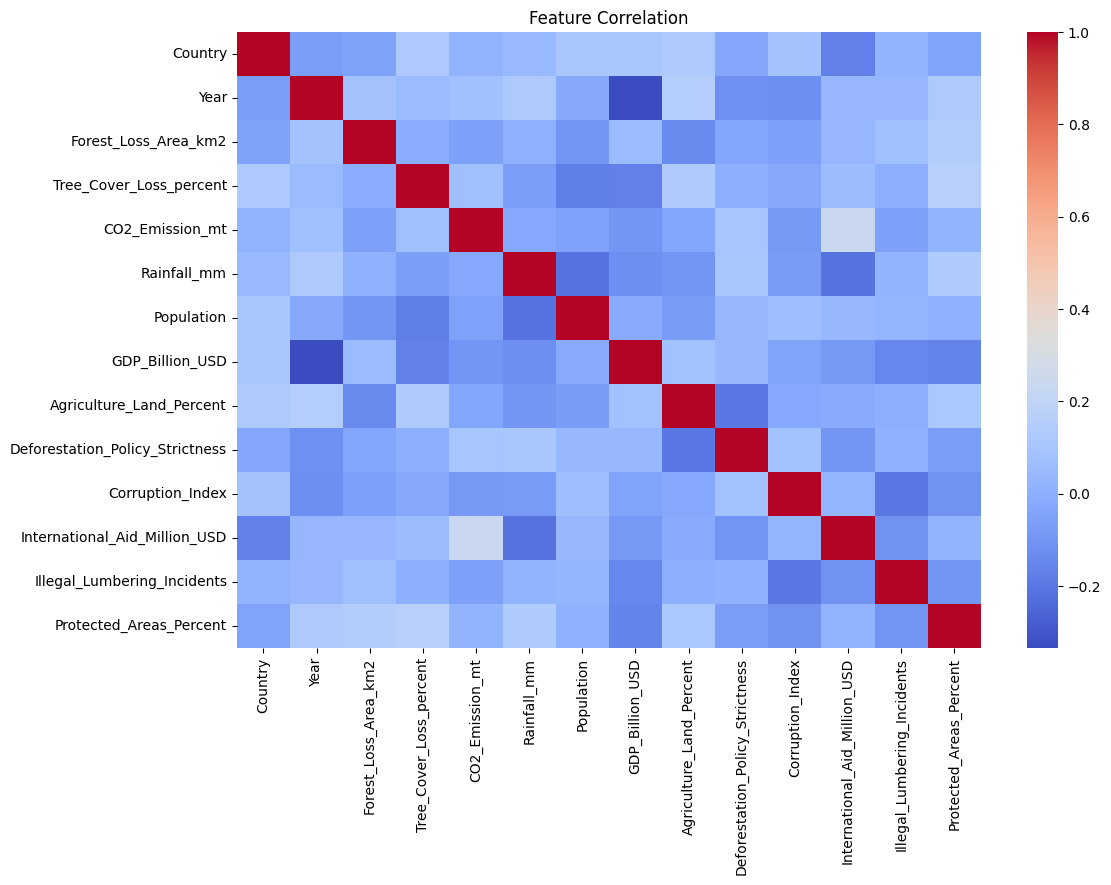

In [13]:
# =====================================
# STEP 12 — CORRELATION
# =====================================

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation")
plt.show()

In [14]:
# =====================================
# STEP 13 — TOP FEATURES
# =====================================

corr_target = df.corr()[target].sort_values(ascending=False)

print("Most Influential Features:\n")
print(corr_target)

Most Influential Features:

Tree_Cover_Loss_percent            1.000000
Protected_Areas_Percent            0.165229
Agriculture_Land_Percent           0.129942
Country                            0.119854
CO2_Emission_mt                    0.069444
International_Aid_Million_USD      0.054942
Year                               0.046684
Illegal_Lumbering_Incidents        0.001482
Deforestation_Policy_Strictness   -0.002262
Forest_Loss_Area_km2              -0.012936
Corruption_Index                  -0.022345
Rainfall_mm                       -0.063606
GDP_Billion_USD                   -0.168258
Population                        -0.175613
Name: Tree_Cover_Loss_percent, dtype: float64


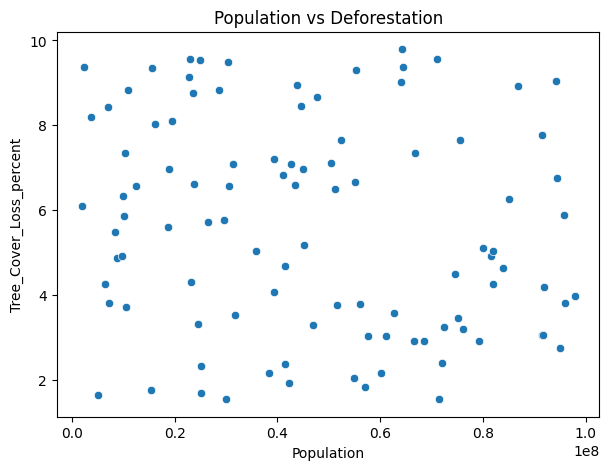

In [15]:
# =====================================
# STEP 14 — SCATTER PLOT
# =====================================

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Population"],
    y=df[target]
)

plt.title("Population vs Deforestation")
plt.show()

In [16]:
# =====================================
# STEP 15 — INTERPRETATION
# =====================================

print("\n📌 KEY INSIGHTS")

print("""
• Population growth is strongly linked to deforestation.
• Economic development influences forest loss patterns.
• CO2 emissions correlate with environmental degradation.
• Policy strictness plays a critical role in mitigation.
""")


📌 KEY INSIGHTS

• Population growth is strongly linked to deforestation.
• Economic development influences forest loss patterns.
• CO2 emissions correlate with environmental degradation.
• Policy strictness plays a critical role in mitigation.



In [17]:
# =====================================
# STEP 16 — RECOMMENDATIONS
# =====================================

print("\n🌳 RECOMMENDATIONS FOR MITIGATION")

print("""
• Strengthen environmental policies and enforcement.
• Promote sustainable land-use practices.
• Increase investment in reforestation programs.
• Control illegal logging activities.
• Encourage renewable energy adoption to reduce forest dependence.
""")


🌳 RECOMMENDATIONS FOR MITIGATION

• Strengthen environmental policies and enforcement.
• Promote sustainable land-use practices.
• Increase investment in reforestation programs.
• Control illegal logging activities.
• Encourage renewable energy adoption to reduce forest dependence.



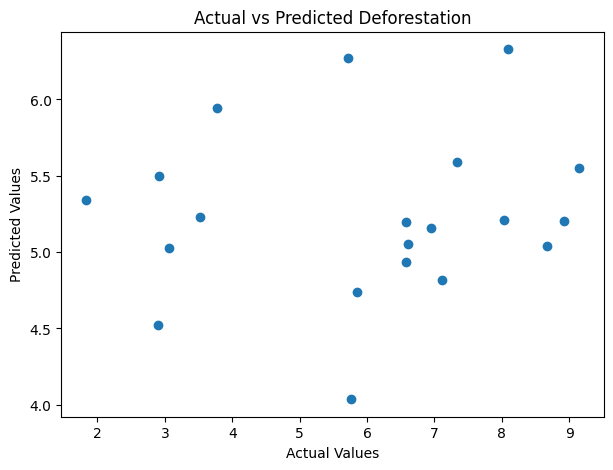

In [18]:
# =====================================
# STEP 17 — ACTUAL vs PREDICTED
# =====================================

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Deforestation")
plt.show()

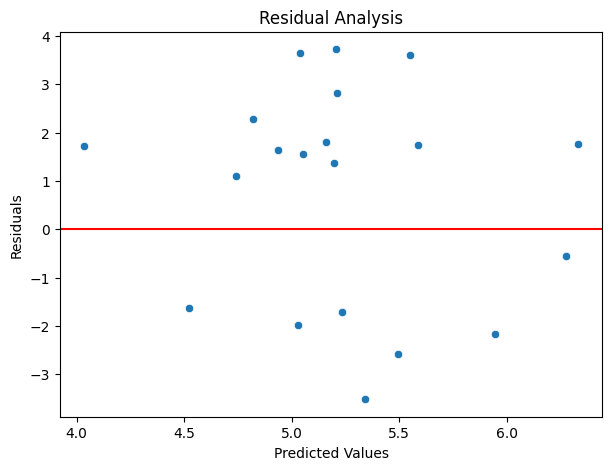

In [19]:
# =====================================
# STEP 18 — RESIDUAL PLOT
# =====================================

residuals = y_test - y_pred_best

plt.figure(figsize=(7,5))

sns.scatterplot(x=y_pred_best, y=residuals)

plt.axhline(0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Analysis")
plt.show()

In [20]:
# =====================================
# STEP 19 — FINAL METRICS
# =====================================

print("\n📊 FINAL MODEL PERFORMANCE")

print(f"MAE : {mean_absolute_error(y_test, y_pred_best):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.3f}")
print(f"R2  : {r2_score(y_test, y_pred_best):.3f}")


📊 FINAL MODEL PERFORMANCE
MAE : 2.146
RMSE: 2.317
R2  : -0.124


In [21]:
# =====================================
# STEP 20 — CROSS VALIDATION
# =====================================

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_svm,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("\nCross-Validation R2 Scores:", scores)
print("Average CV R2:", scores.mean())


Cross-Validation R2 Scores: [-0.10062103 -0.118915    0.01850948 -0.2934212   0.08882921]
Average CV R2: -0.08112370779351452


In [22]:
# =====================================
# STEP 21 — FINAL CONCLUSION
# =====================================

print("\n📌 FINAL CONCLUSION")

print("""
• The SVM model successfully predicts deforestation levels based on socio-economic and environmental factors.
• Population, GDP, emissions, and policy measures significantly influence forest loss.
• Hyperparameter tuning improved model performance.
• Data-driven insights can guide effective deforestation mitigation strategies.
• Combining policy enforcement with sustainable development is essential for long-term forest conservation.
""")


📌 FINAL CONCLUSION

• The SVM model successfully predicts deforestation levels based on socio-economic and environmental factors.
• Population, GDP, emissions, and policy measures significantly influence forest loss.
• Hyperparameter tuning improved model performance.
• Data-driven insights can guide effective deforestation mitigation strategies.
• Combining policy enforcement with sustainable development is essential for long-term forest conservation.



In [23]:
# =====================================
# STEP 22 — SAVE OUTPUT
# =====================================

results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_best
})

results_df.to_csv("svm_deforestation_predictions.csv", index=False)

print("Predictions saved successfully ✅")

Predictions saved successfully ✅
